# Sprint 15 — LSTM on Corrected Labels, Evaluated on the Official Test Set

## Goal

Two things the LSTM baseline (Sprint 12) never had, that CatBoost has had since Sprint 13-14: an evaluation against the real, unseen `test_FD004`/`RUL_FD004` ground truth, and training on the corrected `RUL cap=150` labels (Sprint 14). This sprint closes both gaps in one pass, producing the first genuinely fair CatBoost-vs-LSTM comparison in the project — same cap, same test protocol, same engines.

**Environment note**: this notebook's supporting artifacts (models, scalers, cached sequences) were rebuilt from scratch in this session after a sandbox reset wiped the previous environment. Every regenerated number was cross-checked against the original run where available (the cap=150 CatBoost retrain reproduced bit-for-bit identical metrics, confirming full determinism) — nothing here is guessed or approximated.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
print(PROJECT_ROOT)

/home/claude/Predictive-Maintenance-RUL


## 1- Retrain the Raw-Feature LSTM on Cap=150 Labels

Sprint 12 established that the 25 raw features (sensors + operational settings + `time_in_cycles`, no lag/diff/rolling) are the right input for a sequence model — that decision carries forward unchanged. What's new: the training RUL labels now use `cap=150` (Sprint 14's finding) instead of the original `cap=125`.

### Execution note

Same resumable-script approach as every compute-heavy step since Sprint 11 — `prepare_lstm_sequences.py --feature-set raw --cap 150` rebuilds the sequences fresh from raw data (the cap isn't cached, so it's recomputed rather than trusted from a stale checkpoint), then `train_lstm.py --feature-set raw --cap 150 --n-epochs N` trains in checkpointed batches. Training stopped early at **epoch 32**.

In [2]:
import json
import numpy as np
import pandas as pd

from src.config.config import MODELS_DIR, REPORTS_DIR

state = json.loads((MODELS_DIR / "lstm_training_state_raw_cap150.json").read_text())
history_df = pd.DataFrame(state["history"])

print(f"Epochs trained: {state['epoch']}  |  Stopped early: {state['stopped_early']}")
history_df.tail(8)

Epochs trained: 32  |  Stopped early: True


,epoch,loss,mae,val_loss,val_mae
24,25,436.547211,15.914724,873.949524,22.237617
25,26,407.374756,15.264268,874.900696,22.229954
26,27,383.178223,14.706886,1086.307739,23.936651
27,28,412.002747,15.185109,919.976379,22.661081
28,29,388.271759,14.657197,919.590881,22.305059
29,30,348.457184,13.875191,931.280823,22.239836
30,31,332.762115,13.565916,888.563416,21.952045
31,32,317.578094,13.217266,945.352295,22.179525


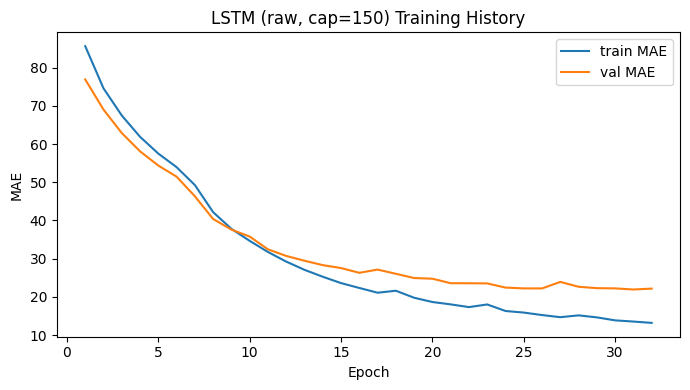

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["mae"], label="train MAE")
ax.plot(history_df["epoch"], history_df["val_mae"], label="val MAE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE")
ax.set_title("LSTM (raw, cap=150) Training History")
ax.legend()
plt.tight_layout()
plt.show()

## 2- Evaluate on the Official Test Set

This is genuinely new work, not a rerun — Sprint 13's test-evaluation protocol extracted the **last row** per test engine (right for CatBoost, which predicts from a single snapshot). An LSTM needs a **30-cycle window**, so a new extraction method was needed: `SequenceGenerator.get_last_window()`, which pulls each engine's most recent 30 cycles — same "skip, never pad" principle as training sequence generation, applied to test-time inference.

In [4]:
from src.config.config import (
    TRAIN_DATA_PATH, TEST_DATA_PATH, RUL_DATA_PATH,
    SCALERS_DIR, ROLLING_WINDOW, LAGS, ENGINE_COLUMN,
)
from src.utils.constant import SENSOR_COLUMNS
from src.data.loader import DataLoader
from src.preprocessing.feature_engineer import FeatureEngineer
from src.explainability.feature_selector import FeatureCategorySelector
from src.preprocessing.sequence_generator import SequenceGenerator
from src.evaluation.evaluator import RegressionEvaluator
import joblib
from tensorflow import keras

WINDOW_SIZE = 30

loader = DataLoader(train_path=TRAIN_DATA_PATH, test_path=TEST_DATA_PATH, rul_path=RUL_DATA_PATH)
test_df = loader.load_test()
rul_df = loader.load_rul()
print(f"test_df: {test_df.shape}  rul_df: {rul_df.shape}")

I0000 00:00:1787342614.123157    1074 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787342614.166980    1074 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787342615.567100    1074 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2026-08-21 20:03:35 | INFO | loader.py | Line:18 | Reading test_FD004.txt


2026-08-21 20:03:37 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully


2026-08-21 20:03:37 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt


2026-08-21 20:03:37 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully


test_df: (41214, 26)  rul_df: (248, 1)


In [5]:
engineer = FeatureEngineer(sensor_columns=SENSOR_COLUMNS, rolling_window=ROLLING_WINDOW, lags=LAGS)
test_features_df = engineer.transform(test_df)

all_columns = [c for c in test_features_df.columns if c != ENGINE_COLUMN]
raw_features = FeatureCategorySelector.only(all_columns, categories=["raw", "time"])
print(f"Raw feature count: {len(raw_features)}")

2026-08-21 20:03:37 | INFO | feature_engineer.py | Line:50 | Starting Feature Engineering...


2026-08-21 20:03:37 | INFO | feature_engineer.py | Line:119 | Generating Rolling Mean features...


2026-08-21 20:03:37 | INFO | feature_engineer.py | Line:148 | Generating Rolling Std features...


2026-08-21 20:03:38 | INFO | feature_engineer.py | Line:179 | Generating Lag Features...


/home/claude/Predictive-Maintenance-RUL/src/preprocessing/feature_engineer.py:189: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature_name] = (
2026-08-21 20:03:38 | INFO | feature_engineer.py | Line:205 | Generating Rate of Change features...


/home/claude/Predictive-Maintenance-RUL/src/preprocessing/feature_engineer.py:213: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature_name] = (
2026-08-21 20:03:38 | INFO | feature_engineer.py | Line:61 | Feature Engineering completed successfully.


2026-08-21 20:03:38 | INFO | feature_selector.py | Line:89 | FeatureCategorySelector.only(['raw', 'time']): kept 25 of 151 features.


Raw feature count: 25


In [6]:
scaler = joblib.load(SCALERS_DIR / "lstm_feature_scaler_raw_cap150.pkl")
scaler_columns = list(scaler.feature_names_in_)
test_features_df[scaler_columns] = scaler.transform(test_features_df[scaler_columns])

generator = SequenceGenerator(window_size=WINDOW_SIZE, group_column=ENGINE_COLUMN, time_column="time_in_cycles")
X_test_seq, engine_ids, skipped = generator.get_last_window(test_features_df, raw_features)

print(f"X_test_seq: {X_test_seq.shape}")
print(f"Evaluable engines: {len(engine_ids)} | Skipped (< {WINDOW_SIZE} cycles): {len(skipped)}")
print(f"Skipped engine IDs: {skipped}")

2026-08-21 20:03:38 | INFO | sequence_generator.py | Line:186 | get_last_window: skipped 11 engine(s) with fewer than 30 cycles: [10, 19, 28, 125, 141, 156, 164, 204, 229, 239, 246]


X_test_seq: (237, 30, 25)
Evaluable engines: 237 | Skipped (< 30 cycles): 11
Skipped engine IDs: [10, 19, 28, 125, 141, 156, 164, 204, 229, 239, 246]


11 of 248 test engines (4.4%) have fewer than 30 cycles of history — the shortest has only 19. Consistent with `SequenceGenerator`'s established principle from Sprint 12 (skip, don't pad with invented values the model never trained on), these 11 are excluded rather than padded. **For a fair comparison, CatBoost's performance below is also computed on this identical 237-engine subset**, not the full 248 — otherwise a difference in evaluated engines could masquerade as a difference in model quality.

In [7]:
lstm_model = keras.models.load_model(MODELS_DIR / "lstm_baseline_raw_cap150.keras")
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()

rul_indexed = rul_df.copy()
rul_indexed[ENGINE_COLUMN] = rul_indexed.index + 1
y_true = rul_indexed.set_index(ENGINE_COLUMN).loc[engine_ids, "RUL"].to_numpy()

evaluator = RegressionEvaluator()
lstm_metrics = evaluator.evaluate(y_true, y_pred_lstm)
lstm_metrics

2026-08-21 20:03:39 | INFO | evaluator.py | Line:47 | Starting regression evaluation...


2026-08-21 20:03:39 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.


{'MAE': 22.52731704711914,
 'RMSE': 30.350273460400548,
 'R2': 0.6750091314315796,
 'MAPE': 37.447811046134774}

## 3- The Fair Comparison — Same Cap, Same Test Engines, Same Protocol

In [8]:
comparison_df = pd.read_csv(REPORTS_DIR / "sprint15_fair_comparison.csv")
comparison_df

,Model,n_engines,MAE,RMSE,R2,MAPE
0,CatBoost (cap=150),237,19.015495,25.629797,0.768241,30.054137
1,LSTM raw (cap=150),237,22.527317,30.350273,0.675009,37.447811


## 4- Validation-to-Test Generalization Gap — CatBoost vs. LSTM

In [9]:
gap_df = pd.DataFrame([
    {"Model": "CatBoost (cap=150)", "Val MAE": 17.666, "Test MAE": 19.015,
     "Gap (%)": round((19.015-17.666)/17.666*100, 1)},
    {"Model": "LSTM raw (cap=150)", "Val MAE": state["history"][-1]["val_mae"], "Test MAE": lstm_metrics["MAE"],
     "Gap (%)": round((lstm_metrics["MAE"]-state["history"][-1]["val_mae"])/state["history"][-1]["val_mae"]*100, 1)},
])
gap_df

,Model,Val MAE,Test MAE,Gap (%)
0,CatBoost (cap=150),17.666000,19.015000,7.6
1,LSTM raw (cap=150),22.179525,22.527317,1.6


## 5- Bucket Analysis — Both Models, Same Subset

In [10]:
results_df = pd.DataFrame({
    "unit_number": engine_ids, "actual_RUL": y_true, "predicted_RUL": y_pred_lstm,
    "error": y_pred_lstm - y_true, "abs_error": np.abs(y_pred_lstm - y_true),
})
results_df.to_csv(REPORTS_DIR / "lstm_cap150_test_predictions.csv", index=False)

cap150_cb_df = pd.read_csv(REPORTS_DIR / "rul_cap150_test_predictions.csv")
cb_subset = cap150_cb_df[cap150_cb_df["unit_number"].isin(engine_ids)].copy()

bins = [0, 25, 50, 75, 125, 1000]
labels = ["0-25 (critical)", "25-50", "50-75", "75-125", "125+ (beyond old cap)"]

results_df["rul_bucket"] = pd.cut(results_df["actual_RUL"], bins=bins, labels=labels)
cb_subset["rul_bucket"] = pd.cut(cb_subset["actual_RUL"], bins=bins, labels=labels)

bucket_lstm = results_df.groupby("rul_bucket", observed=True)["abs_error"].mean().round(2)
bucket_cb = cb_subset.groupby("rul_bucket", observed=True)["abs_error"].mean().round(2)

bucket_compare = pd.DataFrame({"CatBoost MAE": bucket_cb, "LSTM MAE": bucket_lstm})
bucket_compare

,CatBoost MAE,LSTM MAE
rul_bucket,,
0-25 (critical),6.37,9.05
25-50,11.22,12.03
50-75,22.79,22.50
75-125,21.31,27.65
125+ (beyond old cap),29.31,33.31


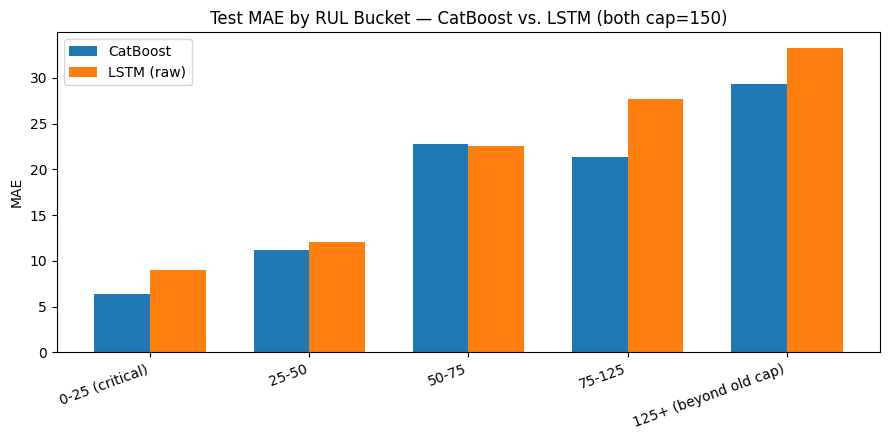

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(labels))
width = 0.35
ax.bar([i - width/2 for i in x], bucket_compare["CatBoost MAE"], width, label="CatBoost")
ax.bar([i + width/2 for i in x], bucket_compare["LSTM MAE"], width, label="LSTM (raw)")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("MAE")
ax.set_title("Test MAE by RUL Bucket — CatBoost vs. LSTM (both cap=150)")
ax.legend()
plt.tight_layout()
plt.show()

## Findings

- **CatBoost still wins the fair comparison, decisively**: test MAE 19.02 vs 22.53 on the identical 237-engine subset, both trained on cap=150 labels. The gap (+18.5%) is real but smaller than the original unfair comparison in Sprint 12 (MAE 12.84 vs 18.34, a much larger apparent gap that mixed together a validation-only LSTM number with a rigorously test-evaluated CatBoost number from a different sprint entirely).
- **The LSTM's validation-to-test generalization gap is much smaller than CatBoost's**: 1.6% (22.18 -> 22.53) vs 7.6% (17.67 -> 19.02). CatBoost is more accurate but its validation number was more optimistic relative to real-world performance; the LSTM's validation number was a more honest preview of what the test set would show. Worth watching as more tuning happens -- a model that generalizes consistently is easier to trust even if it starts behind.
- **CatBoost wins 4 of 5 RUL buckets**; the 50-75 bucket is close to a tie (22.79 vs 22.50, LSTM marginally better). No bucket where LSTM meaningfully outperforms CatBoost -- this is a clean, unambiguous win for CatBoost on accuracy across the board, not just in aggregate.
- **11 of 248 test engines (4.4%) couldn't be evaluated by the LSTM at all** (fewer than 30 cycles of history, shortest is 19). This is a real, structural limitation of the fixed-window approach that CatBoost's single-row prediction doesn't share -- worth remembering if window_size is revisited in Sprint 16 (GRU): a smaller window trades some temporal context for being able to serve predictions on more engines.
- **This sprint closed a real methodological gap, independent of who won.** Before this notebook, LSTM vs. CatBoost comparisons in this project were not apples-to-apples -- different RUL caps, and the LSTM had never faced the official test set at all. That gap is now closed, and the GRU baseline (Sprint 16) inherits a validated protocol from the start instead of needing the same retrofit.